# Optativa III: Ciencia de Datos
## Semana 4 — Transformación de datos

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 4 · Sesión 2**

---

### Propósito

Una vez que los datos están limpios, hay que **transformarlos** para que los algoritmos puedan aprovecharlos. En esta actividad dominarás las cinco técnicas centrales de transformación de datos:

- **Normalización** (Min-Max) — llevar variables a un rango común [0, 1].
- **Estandarización** (Z-score) — centrar en media 0 y desviación 1.
- **Codificación de variables categóricas** — convertir texto en números (ordinal, one-hot, label encoding).
- **Feature engineering** — crear variables nuevas más informativas.
- **Manejo de fechas** — extraer información útil de columnas temporales.

Al final construirás un **pipeline de transformación reproducible** y prepararás un **dataset limpio con su diccionario de datos**.

La actividad tiene dos partes:

- **PARTE A — Ejemplo guiado por el profesor.** Transformaremos juntos un dataset de empleados, paso a paso.
- **PARTE B — Tu turno.** Aplicarás las técnicas de forma autónoma sobre otros datos y construirás tu propio pipeline.

Responderás **50 preguntas ✍️** modificando código, analizando resultados e interpretando.

### Los datasets (súbelos a Colab antes de empezar)

- `empleados.csv` — datos de 500 empleados (numéricas, categóricas y fechas). Para la Parte A.
- `amazon.csv` — productos de Amazon (ya limpio). Para la Parte B.

Sube ambos con el panel de archivos de Colab (icono de carpeta → subir).

### Cómo trabajar

Ejecuta cada celda con **Shift + Enter** en orden, responde las preguntas ✍️, completa los retos y, al final, guarda una copia en Drive y entrégala en Classroom.


---
# PARTE A — Ejemplo guiado por el profesor

## Paso 0 — Carga y exploración


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

pd.set_option("display.max_columns", None)

df = pd.read_csv("empleados.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (500, 11)


,empleado_id,departamento,nivel,ciudad,educacion,edad,salario_mensual,horas_semana,proyectos_completados,satisfaccion,fecha_ingreso
0,1000,Ventas,Junior,Querétaro,Licenciatura,24,28193.13,49,10,1.6,2016-08-18
1,1001,Marketing,Lead,Monterrey,Licenciatura,23,59236.19,52,10,4.4,2017-01-12
2,1002,Recursos Humanos,Junior,Puebla,Licenciatura,27,33076.34,47,5,4.7,2017-11-30
3,1003,Finanzas,Lead,Puebla,Técnico,56,89067.13,37,10,2.8,2020-06-16
4,1004,Ventas,Lead,Querétaro,Doctorado,45,73832.11,38,6,2.4,2023-03-18


In [2]:
# Identificamos tipos de variable
print("Tipos de datos:")
print(df.dtypes)
print("\nVariables numericas:", df.select_dtypes(include="number").columns.tolist())
print("Variables categoricas:", df.select_dtypes(include="object").columns.tolist())

Tipos de datos:
empleado_id                int64
departamento                 str
nivel                        str
ciudad                       str
educacion                    str
edad                       int64
salario_mensual          float64
horas_semana               int64
proyectos_completados      int64
satisfaccion             float64
fecha_ingreso                str
dtype: object

Variables numericas: ['empleado_id', 'edad', 'salario_mensual', 'horas_semana', 'proyectos_completados', 'satisfaccion']
Variables categoricas: ['departamento', 'nivel', 'ciudad', 'educacion', 'fecha_ingreso']


C:\Users\REYES\AppData\Local\Temp\ipykernel_556\3823140606.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Variables categoricas:", df.select_dtypes(include="object").columns.tolist())


> ✍️ **1.** ¿Cuántos empleados y cuántas variables tiene el dataset? Enumera qué variables son numéricas y cuáles categóricas.

> ✍️ **2.** ¿Por qué necesitamos "transformar" los datos si ya están limpios? ¿Qué problema tiene alimentar a un algoritmo con `salario_mensual` (decenas de miles) y `satisfaccion` (1 a 5) en sus escalas originales?

> ✍️ **3.** La columna `fecha_ingreso` aparece como `object` (texto). ¿Por qué pandas no la reconoce automáticamente como fecha? ¿Qué tendremos que hacer con ella?

**Respuestas:**

1. El dataset tiene 500 empleados y 11 variables. Numéricas: `empleado_id`, `edad`, `salario_mensual`, `horas_semana`, `proyectos_completados` y `satisfaccion`. Categóricas o de texto: `departamento`, `nivel`, `ciudad`, `educacion` y `fecha_ingreso`. `nivel` y `educacion` tienen orden; departamento y ciudad son nominales.

2. Estar limpio no significa estar listo para cualquier algoritmo. `salario_mensual` tiene valores mucho mayores que `satisfaccion`, por lo que dominaría distancias, regularización y algunos métodos de optimización. Hay que escalar para que cada variable contribuya de forma comparable.

3. Pandas recibe la columna como texto y no puede asumir de forma segura que todos los formatos representan fechas. Debemos convertirla explícitamente con `pd.to_datetime()` y después extraer año, mes, día de la semana o antigüedad.


## Paso 1 — Normalización (Min-Max Scaling)

La **normalización** transforma una variable a un rango fijo, típicamente [0, 1], con la fórmula:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Es útil cuando quieres que todas las variables tengan el mismo peso en algoritmos basados en distancias.


Salario original -> min: 21533  max: 128668
Salario normalizado -> min: 0.000  max: 1.000


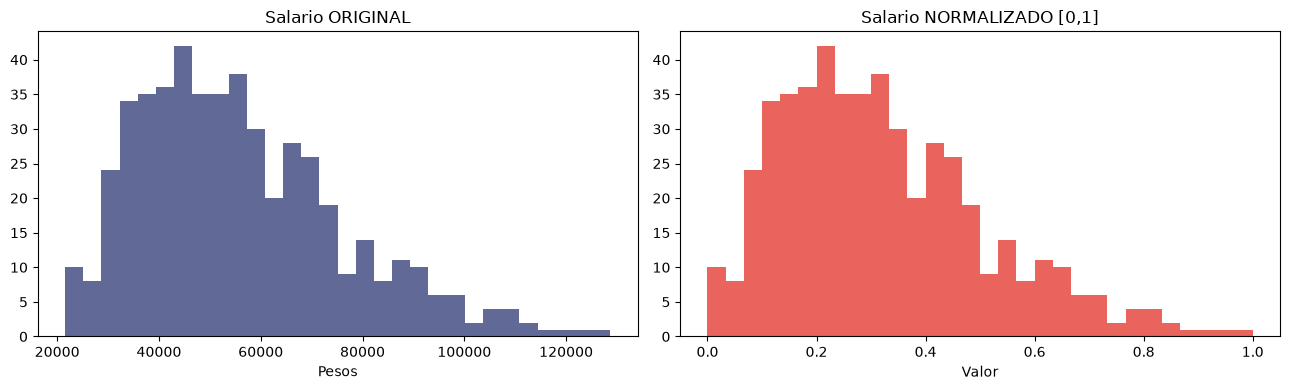

In [3]:
# Normalizamos el salario a [0, 1]
scaler_mm = MinMaxScaler()
df["salario_norm"] = scaler_mm.fit_transform(df[["salario_mensual"]])

print("Salario original -> min: {:.0f}  max: {:.0f}".format(
    df["salario_mensual"].min(), df["salario_mensual"].max()))
print("Salario normalizado -> min: {:.3f}  max: {:.3f}".format(
    df["salario_norm"].min(), df["salario_norm"].max()))

# Visualizamos antes y despues
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].hist(df["salario_mensual"], bins=30, color="#1e2a6b", alpha=0.7)
axes[0].set_title("Salario ORIGINAL"); axes[0].set_xlabel("Pesos")
axes[1].hist(df["salario_norm"], bins=30, color="#e2231a", alpha=0.7)
axes[1].set_title("Salario NORMALIZADO [0,1]"); axes[1].set_xlabel("Valor")
plt.tight_layout(); plt.show()

> ✍️ **4.** Tras normalizar, ¿cuál es el valor mínimo y máximo de `salario_norm`? ¿A qué salario original corresponde el valor 0 y a cuál el valor 1?

> ✍️ **5.** Compara los dos histogramas. ¿Cambió la **forma** de la distribución al normalizar, o solo la **escala** del eje X? Explica.

> ✍️ **6.** La normalización Min-Max es sensible a los valores atípicos. Si hubiera un salario de 10 millones (outlier), ¿qué pasaría con el resto de los valores normalizados? (Pista: piensa dónde quedaría el máximo.)

**Respuestas:**

4. El mínimo de `salario_norm` es 0 y el máximo es 1. El 0 corresponde al salario mínimo original, 21,533.05 pesos, y el 1 al máximo, 128,668.39 pesos.

5. La forma de los histogramas se conserva; solo cambia la escala del eje X. La normalización es una transformación lineal, así que no corrige sesgo ni modifica el orden relativo de los salarios.

6. El salario de 10 millones se convertiría en el nuevo máximo y recibiría el valor 1. Los demás salarios quedarían comprimidos cerca de 0, perdiendo resolución y haciendo más difícil distinguirlos.


### 🔧 Reto 1 — Normaliza otra variable

Normaliza la columna `edad` a [0, 1] creando `edad_norm`. Verifica su mínimo y máximo.


In [4]:
# RETO: normaliza edad
# df["edad_norm"] = scaler_mm.fit_transform(df[["edad"]])
# print(df["edad_norm"].describe())


> ✍️ **7.** ¿Cuál es la edad mínima y máxima del dataset? ¿A qué valor normalizado corresponde un empleado de edad promedio?

**Respuesta:**

7. La edad mínima es 22 años y la máxima 59. La edad promedio es 40.04 años; al normalizarla corresponde aproximadamente a `(40.04 - 22) / (59 - 22) = 0.487`, es decir, cerca de 0.49.


## Paso 2 — Estandarización (Z-score)

La **estandarización** centra la variable en media 0 y desviación estándar 1:

$$z = \frac{x - \mu}{\sigma}$$

Un valor de z = 2 significa "2 desviaciones estándar por encima de la media". Es la transformación preferida para muchos modelos estadísticos y de machine learning.


In [5]:
# Estandarizamos el salario (Z-score)
scaler_z = StandardScaler()
df["salario_z"] = scaler_z.fit_transform(df[["salario_mensual"]])

print("Salario estandarizado:")
print("  media: {:.4f}  (debe ser ~0)".format(df["salario_z"].mean()))
print("  desviacion: {:.4f}  (debe ser ~1)".format(df["salario_z"].std()))
print("  min: {:.2f}  max: {:.2f}".format(df["salario_z"].min(), df["salario_z"].max()))

# Un empleado con salario muy alto tendra z grande
ejemplo = df.nlargest(1, "salario_mensual")[["salario_mensual", "salario_z"]]
print("\nEmpleado mejor pagado:")
print(ejemplo.to_string(index=False))

Salario estandarizado:
  media: -0.0000  (debe ser ~0)
  desviacion: 1.0010  (debe ser ~1)
  min: -1.72  max: 3.62

Empleado mejor pagado:
 salario_mensual  salario_z
       128668.39   3.619058


> ✍️ **8.** Tras estandarizar, ¿cuál es la media y la desviación estándar de `salario_z`? ¿Por qué siempre dan 0 y 1?

> ✍️ **9.** El empleado mejor pagado tiene un `salario_z` de cierto valor. Interprétalo: ¿cuántas desviaciones estándar por encima del promedio está?

> ✍️ **10.** ¿Cuál es la diferencia clave entre **normalización** (Min-Max) y **estandarización** (Z-score)? ¿En qué caso usarías cada una?

> ✍️ **11.** A diferencia de la normalización, la estandarización NO acota los valores a un rango fijo. ¿Entre qué valores puede moverse un z-score en la práctica? ¿Puede ser negativo?

**Respuestas:**

8. La media de `salario_z` es aproximadamente 0 y su desviación estándar poblacional es 1; la desviación calculada por pandas muestra 1.001 por usar el ajuste muestral. Esto ocurre porque el escalador resta la media y divide entre la desviación estándar.

9. El empleado mejor pagado tiene `salario_z = 3.619058`, por lo que está aproximadamente 3.62 desviaciones estándar por encima del salario promedio.

10. Min-Max lleva los valores a un intervalo fijo, normalmente [0, 1], y es útil en métodos basados en distancias o cuando se necesita un rango acotado. Z-score centra en media 0 y desviación 1, y es útil para comparar variables o modelos estadísticos; no queda limitado a un intervalo.

11. Un z-score puede tomar cualquier valor real, aunque la mayoría suele concentrarse aproximadamente entre -3 y 3. Sí puede ser negativo: significa que el valor está por debajo de la media.


### 🔧 Reto 2 — Estandariza y compara

Estandariza la columna `horas_semana` creando `horas_z`. Luego encuentra al empleado con el z-score más alto (el que más horas trabaja) usando `df.nlargest()`.


In [6]:
# RETO: estandariza horas_semana y encuentra el maximo
# df["horas_z"] = scaler_z.fit_transform(df[["horas_semana"]])
# print(df.nlargest(3, "horas_z")[["horas_semana", "horas_z"]])


> ✍️ **12.** ¿Cuántas horas trabaja el empleado con el z-score más alto y cuál es ese z-score? ¿Está muy lejos de la media?

**Respuesta:**

12. El máximo corresponde a 54 horas semanales y un z-score aproximado de 1.705. Está 1.7 desviaciones estándar sobre la media: es alto, pero no constituye un valor extremadamente alejado.


## Paso 3 — Codificación de variables categóricas

Los algoritmos no entienden texto. Hay que convertir las categorías en números. Existen tres técnicas según el tipo de variable.

### 3.1 — Codificación ORDINAL (para categorías con orden)

`nivel` (Junior < Semi-Senior < Senior < Lead) y `educacion` tienen un **orden natural**. Les asignamos números que respeten ese orden.


In [7]:
# Codificacion ordinal: respetamos la jerarquia
orden_nivel = {"Junior": 1, "Semi-Senior": 2, "Senior": 3, "Lead": 4}
df["nivel_cod"] = df["nivel"].map(orden_nivel)

orden_educacion = {"Técnico": 1, "Licenciatura": 2, "Maestría": 3, "Doctorado": 4}
df["educacion_cod"] = df["educacion"].map(orden_educacion)

print("Codificacion de nivel:")
print(df[["nivel", "nivel_cod"]].drop_duplicates().sort_values("nivel_cod").to_string(index=False))

Codificacion de nivel:
      nivel  nivel_cod
     Junior          1
Semi-Senior          2
     Senior          3
       Lead          4


> ✍️ **13.** ¿Por qué asignamos números en orden (1, 2, 3, 4) a `nivel` en lugar de números al azar? ¿Qué información se perdería si usáramos códigos aleatorios?

> ✍️ **14.** ¿Qué pasaría si a `educacion` (que SÍ tiene orden) la codificáramos con one-hot (sin orden)? ¿Perderíamos información?

**Respuestas:**

13. Los números respetan la jerarquía real: Junior < Semi-Senior < Senior < Lead. Con códigos aleatorios se perdería esa relación y el modelo no podría interpretar que pasar de un nivel a otro representa mayor responsabilidad.

14. One-hot no perdería la identidad de cada nivel, pero ocultaría su orden y usaría más columnas. Para modelos donde el efecto es aproximadamente progresivo, la codificación ordinal conserva mejor la información y es más compacta; one-hot es útil si el efecto no es monotónico.


### 3.2 — Codificación ONE-HOT (para categorías sin orden)

`departamento` y `ciudad` **no tienen orden** (Ventas no es "mayor" que Marketing). Para ellas usamos **one-hot encoding**: creamos una columna binaria (0/1) por cada categoría.


In [8]:
# One-hot encoding del departamento
dummies_dep = pd.get_dummies(df["departamento"], prefix="dep")
print("Columnas creadas por one-hot:")
print(dummies_dep.columns.tolist())
print("\nEjemplo (primeras filas):")
print(dummies_dep.head())

# Unimos al dataframe
df = pd.concat([df, dummies_dep], axis=1)
print("\nDimensiones tras one-hot:", df.shape)

Columnas creadas por one-hot:
['dep_Finanzas', 'dep_Marketing', 'dep_Recursos Humanos', 'dep_Tecnología', 'dep_Ventas']

Ejemplo (primeras filas):
   dep_Finanzas  dep_Marketing  dep_Recursos Humanos  dep_Tecnología  \
0         False          False                 False           False   
1         False           True                 False           False   
2         False          False                  True           False   
3          True          False                 False           False   
4         False          False                 False           False   

   dep_Ventas  
0        True  
1       False  
2       False  
3       False  
4        True  

Dimensiones tras one-hot: (500, 20)


> ✍️ **15.** ¿Cuántas columnas nuevas creó el one-hot encoding de `departamento`? ¿Por qué esa cantidad?

> ✍️ **16.** En una fila donde `departamento = "Ventas"`, ¿qué valor tendrá la columna `dep_Ventas` y qué valor las demás columnas `dep_...`?

> ✍️ **17.** ¿Por qué NO usamos one-hot para `nivel`? ¿Qué problema traería convertir una variable ordinal en columnas one-hot independientes?

> ✍️ **18.** El one-hot puede crear muchísimas columnas si la variable tiene muchas categorías (ej. 1000 ciudades). ¿Qué problema práctico genera esto? (Investiga el término "maldición de la dimensionalidad".)

**Respuestas:**

15. Creó 5 columnas porque `departamento` tiene cinco categorías: Finanzas, Marketing, Recursos Humanos, Tecnología y Ventas.

16. En una fila de Ventas, `dep_Ventas` vale 1 y las otras columnas `dep_...` valen 0.

17. `nivel` tiene un orden natural, por lo que una columna ordinal conserva esa jerarquía de forma compacta. One-hot separaría los niveles y obligaría al modelo a aprender el orden desde cero; además puede perder eficiencia, aunque sería válido si los efectos no fueran ordenados.

18. Aumentan la memoria, el tiempo de entrenamiento y el riesgo de sobreajuste. La maldición de la dimensionalidad hace que los datos se vuelvan dispersos y que las distancias sean menos informativas cuando crece mucho el número de dimensiones.


### 3.3 — LABEL ENCODING (asignar un número a cada categoría)

`LabelEncoder` asigna un entero a cada categoría. Es rápido, pero **introduce un orden artificial** que no siempre es deseable.


In [9]:
# Label encoding de ciudad
le = LabelEncoder()
df["ciudad_cod"] = le.fit_transform(df["ciudad"])

print("Mapeo de label encoding:")
for i, clase in enumerate(le.classes_):
    print(f"  {clase} -> {i}")

Mapeo de label encoding:
  CDMX -> 0
  Guadalajara -> 1
  Monterrey -> 2
  Puebla -> 3
  Querétaro -> 4


> ✍️ **19.** ¿Qué número le asignó el label encoder a cada ciudad? ¿En qué orden las numeró (pista: alfabético)?

> ✍️ **20.** El label encoding le da a `ciudad` los valores 0,1,2,3,4. Un algoritmo podría interpretar erróneamente que "Querétaro (4) es 4 veces Guadalajara (1)". ¿Por qué es esto un problema para una variable SIN orden? ¿Cuándo sería preferible one-hot?

**Respuestas:**

19. El mapeo es: CDMX = 0, Guadalajara = 1, Monterrey = 2, Puebla = 3 y Querétaro = 4. Se asignaron en orden alfabético.

20. Las ciudades no tienen una distancia ni jerarquía numérica, pero el label encoding hace que el algoritmo interprete que sí existen. One-hot es preferible cuando hay pocas o una cantidad manejable de categorías nominales, como estas cinco ciudades.


### 🔧 Reto 3 — Codifica `educacion` con one-hot

Aunque `educacion` tiene orden, practica el one-hot encoding sobre ella para comparar. Crea las columnas dummy y cuenta cuántas son.


In [10]:
# RETO: one-hot de educacion
# dummies_edu = pd.get_dummies(df["educacion"], prefix="edu")
# print(dummies_edu.columns.tolist())


> ✍️ **21.** ¿Cuántas columnas creó el one-hot de `educacion`? Comparado con la codificación ordinal (una sola columna), ¿cuál ocupa menos espacio? ¿Cuál conserva el orden?

**Respuesta:**

21. Creó 4 columnas, una por cada nivel educativo. La codificación ordinal ocupa menos espacio, una columna, y es la que conserva explícitamente el orden; one-hot conserva las categorías, pero no la jerarquía.


## Paso 4 — Manejo de fechas (feature engineering temporal)

Una columna de fecha es una mina de información. La convertimos a tipo fecha y extraemos variables útiles.


In [11]:
# Convertir a tipo datetime
df["fecha_ingreso"] = pd.to_datetime(df["fecha_ingreso"])
print("Tipo tras conversion:", df["fecha_ingreso"].dtype)

# Extraer componentes de la fecha
df["anio_ingreso"] = df["fecha_ingreso"].dt.year
df["mes_ingreso"] = df["fecha_ingreso"].dt.month
df["dia_semana_ingreso"] = df["fecha_ingreso"].dt.day_name()

# Calcular antiguedad en años (feature derivada muy util)
fecha_referencia = pd.Timestamp("2025-01-01")
df["antiguedad_anios"] = ((fecha_referencia - df["fecha_ingreso"]).dt.days / 365.25).round(1)

print(df[["fecha_ingreso", "anio_ingreso", "mes_ingreso", "antiguedad_anios"]].head())

Tipo tras conversion: datetime64[us]
  fecha_ingreso  anio_ingreso  mes_ingreso  antiguedad_anios
0    2016-08-18          2016            8               8.4
1    2017-01-12          2017            1               8.0
2    2017-11-30          2017           11               7.1
3    2020-06-16          2020            6               4.5
4    2023-03-18          2023            3               1.8


> ✍️ **22.** ¿Qué hace `pd.to_datetime()`? ¿Por qué es necesario antes de poder extraer el año o el mes?

> ✍️ **23.** ¿Qué componentes extrajimos de la fecha? Menciona al menos otros dos que podrías extraer (ej. trimestre, si es fin de semana).

> ✍️ **24.** La `antiguedad_anios` es una **feature derivada**: no estaba en los datos, la calculamos. ¿Por qué es más útil para un análisis de RH que la fecha de ingreso cruda?

> ✍️ **25.** ¿Cuál es la antigüedad promedio de los empleados? Calcúlala en una celda. ¿Y el empleado más antiguo cuántos años lleva?

**Respuestas:**

22. `pd.to_datetime()` convierte texto a un tipo temporal de pandas (`datetime64`), permitiendo usar propiedades como `.dt.year` y `.dt.month` en lugar de tratar la fecha como una cadena.

23. Extrajimos año, mes, día de la semana y antigüedad en años. También podrían extraerse trimestre, semana del año, día del mes, si es fin de semana o una temporada fiscal.

24. La antigüedad resume cuánto tiempo lleva cada persona en la empresa y es directamente interpretable para RH. La fecha cruda requiere calcular esa diferencia cada vez y depende de la fecha de referencia.

25. La antigüedad promedio es aproximadamente 5.0 años y la máxima es 10.0 años.


In [12]:
# Celda para la P25
# print("Antiguedad promedio:", df["antiguedad_anios"].mean().round(1))
# print("Empleado mas antiguo:", df["antiguedad_anios"].max())


## Paso 5 — Feature engineering (crear variables nuevas)

El **feature engineering** es el arte de crear variables que capturen mejor la información. Un buen feature puede mejorar un modelo más que un algoritmo sofisticado.


In [13]:
# Feature 1: salario por proyecto completado (productividad economica)
df["salario_por_proyecto"] = (df["salario_mensual"] /
                              df["proyectos_completados"].replace(0, 1)).round(2)

# Feature 2: categoria de antiguedad (novato / establecido / veterano)
df["categoria_antiguedad"] = pd.cut(df["antiguedad_anios"],
                                    bins=[0, 2, 5, 100],
                                    labels=["Novato", "Establecido", "Veterano"])

# Feature 3: indicador binario de alto desempeño
df["alto_desempeno"] = ((df["proyectos_completados"] > df["proyectos_completados"].median()) &
                        (df["satisfaccion"] > 3.5)).astype(int)

print("Nuevas features creadas:")
print(df[["salario_por_proyecto", "categoria_antiguedad", "alto_desempeno"]].head())
print("\nDistribucion de categoria_antiguedad:")
print(df["categoria_antiguedad"].value_counts())

Nuevas features creadas:
   salario_por_proyecto categoria_antiguedad  alto_desempeno
0               2819.31             Veterano               0
1               5923.62             Veterano               1
2               6615.27             Veterano               0
3               8906.71          Establecido               0
4              12305.35               Novato               0

Distribucion de categoria_antiguedad:
categoria_antiguedad
Veterano       244
Establecido    153
Novato         103
Name: count, dtype: int64


> ✍️ **26.** Explica qué representa cada una de las tres features nuevas. ¿Cuál te parece más útil para predecir el desempeño de un empleado?

> ✍️ **27.** La feature `alto_desempeno` combina DOS condiciones. ¿Cuáles son? ¿Por qué combinar variables puede crear un indicador más potente que cada una por separado?

> ✍️ **28.** ¿Cuántos empleados quedaron en cada `categoria_antiguedad`? ¿Qué grupo es el más numeroso?

> ✍️ **29.** El feature engineering requiere **conocimiento del dominio**. Propón UNA feature nueva que se te ocurra para este dataset de RH y explica por qué sería útil.

**Respuestas:**

26. `salario_por_proyecto` aproxima el salario asociado a cada proyecto completado; `categoria_antiguedad` agrupa a empleados como Novato, Establecido o Veterano; `alto_desempeno` identifica a quien supera la mediana de proyectos y tiene satisfacción mayor a 3.5. Para predecir desempeño elegiría `alto_desempeno` como objetivo o indicador de referencia, aunque no debería usarse como predictor si se construye con la misma información del objetivo.

27. Combina superar la mediana de `proyectos_completados` y tener `satisfaccion > 3.5`. La intersección identifica simultáneamente productividad y satisfacción, reduciendo falsos positivos frente a usar una sola condición.

28. Hay 103 Novatos, 153 Establecidos y 244 Veteranos. El grupo más numeroso es Veterano.

29. Crearía `proyectos_por_hora`, calculada como proyectos completados entre horas semanales. Podría aproximar productividad ajustada por jornada y ayudar a detectar diferencias de eficiencia entre empleados, aunque tendría que validarse y tratarse con cuidado cuando el número de proyectos sea cero.


### 🔧 Reto 4 — Crea tu propia feature

Crea una feature `salario_anual` (salario mensual × 12) y otra `es_senior` (1 si el nivel es Senior o Lead, 0 si no). Usa `.isin()` para la segunda.


In [14]:
# RETO: crea salario_anual y es_senior
# df["salario_anual"] = df["salario_mensual"] * 12
# df["es_senior"] = df["nivel"].isin(["Senior", "Lead"]).astype(int)
# print(df[["salario_anual", "es_senior"]].head())


> ✍️ **30.** ¿Cuántos empleados son "senior" (Senior o Lead) según tu feature? ¿Qué porcentaje del total representan?

**Respuesta:**

30. Hay 147 empleados con nivel Senior o Lead. Representan el 29.4% del total de 500 empleados.


## Paso 6 — Pipeline de transformación reproducible

Un **pipeline** encapsula todos los pasos de transformación en una secuencia ordenada y reutilizable. Esto garantiza **reproducibilidad**: aplicar exactamente las mismas transformaciones a datos nuevos.


In [15]:
def pipeline_transformacion(datos):
    """Aplica todas las transformaciones en orden. Recibe un DataFrame crudo
    y devuelve uno transformado, listo para analisis o modelado."""
    d = datos.copy()

    # 1. Fechas
    d["fecha_ingreso"] = pd.to_datetime(d["fecha_ingreso"])
    fecha_ref = pd.Timestamp("2025-01-01")
    d["antiguedad_anios"] = ((fecha_ref - d["fecha_ingreso"]).dt.days / 365.25).round(1)

    # 2. Codificacion ordinal
    d["nivel_cod"] = d["nivel"].map({"Junior":1, "Semi-Senior":2, "Senior":3, "Lead":4})
    d["educacion_cod"] = d["educacion"].map({"Técnico":1, "Licenciatura":2, "Maestría":3, "Doctorado":4})

    # 3. Estandarizacion de numericas
    for col in ["salario_mensual", "edad", "horas_semana"]:
        d[col + "_z"] = StandardScaler().fit_transform(d[[col]])

    # 4. One-hot de nominales
    d = pd.concat([d, pd.get_dummies(d["departamento"], prefix="dep")], axis=1)

    # 5. Feature derivada
    d["salario_anual"] = d["salario_mensual"] * 12

    return d

# Aplicamos el pipeline al dataset original crudo
df_crudo = pd.read_csv("empleados.csv")
df_transformado = pipeline_transformacion(df_crudo)
print("Dataset crudo:", df_crudo.shape)
print("Dataset transformado:", df_transformado.shape)
print("\nNuevas columnas:", [c for c in df_transformado.columns if c not in df_crudo.columns])

Dataset crudo: (500, 11)
Dataset transformado: (500, 23)

Nuevas columnas: ['antiguedad_anios', 'nivel_cod', 'educacion_cod', 'salario_mensual_z', 'edad_z', 'horas_semana_z', 'dep_Finanzas', 'dep_Marketing', 'dep_Recursos Humanos', 'dep_Tecnología', 'dep_Ventas', 'salario_anual']


> ✍️ **31.** ¿Cuántas columnas nuevas agregó el pipeline? ¿Por qué encapsular las transformaciones en una función es mejor que ejecutarlas sueltas una por una?

> ✍️ **32.** ¿Por qué usamos `datos.copy()` al inicio de la función? ¿Qué pasaría si modificáramos el DataFrame original directamente?

> ✍️ **33.** La **reproducibilidad** es clave en ciencia de datos. Si mañana llegan 100 empleados nuevos, ¿cómo aplicarías exactamente las mismas transformaciones? ¿Por qué el pipeline lo facilita?

**Respuestas:**

31. El pipeline agregó 12 columnas: antigüedad, dos codificaciones ordinales, tres variables estandarizadas, cinco dummies de departamento y salario anual. Encapsularlo evita omisiones, mantiene el orden y permite reutilizarlo con una sola llamada.

32. `datos.copy()` evita modificar el DataFrame original por efectos secundarios. Sin la copia, se agregarían columnas y se convertirían fechas directamente en los datos de entrada, lo que puede causar duplicados o errores al volver a ejecutar pasos.

33. Guardaría la función y, en un flujo de producción, también los escaladores ajustados con los datos históricos. Aplicaría el pipeline a las 100 filas nuevas con la misma fecha de referencia, mapeos y columnas one-hot, garantizando el mismo esquema.


### 🔧 Reto 5 — Amplía el pipeline

Agrega al pipeline un paso que cree la feature `categoria_antiguedad` (Novato/Establecido/Veterano) con `pd.cut()`. Vuelve a ejecutarlo y verifica que aparezca.


In [16]:
# RETO: modifica pipeline_transformacion para agregar categoria_antiguedad
# (copia la funcion, agrega el paso con pd.cut y vuelve a aplicarla)


> ✍️ **34.** Tras ampliar el pipeline, ¿aparece la nueva columna? ¿Por qué es importante que el pipeline sea fácil de modificar y extender?

**Respuesta:**

34. Sí, debe aparecer `categoria_antiguedad` con las categorías Novato, Establecido y Veterano. Que sea extensible permite incorporar nuevas reglas sin romper las anteriores y facilita pruebas, mantenimiento y reutilización.


## Paso 7 — Verificación del dataset transformado


In [17]:
# Comparamos escalas antes y despues de transformar
print("=== COMPARACION DE ESCALAS ===")
print("\nVariables ORIGINALES (escalas muy distintas):")
print(df[["salario_mensual", "edad", "satisfaccion"]].describe().loc[["mean", "std", "min", "max"]])

print("\nVariables ESTANDARIZADAS (misma escala):")
cols_z = ["salario_z"]
if "salario_mensual_z" in df_transformado.columns:
    print(df_transformado[["salario_mensual_z", "edad_z", "horas_semana_z"]].describe().loc[["mean", "std"]])

=== COMPARACION DE ESCALAS ===

Variables ORIGINALES (escalas muy distintas):
      salario_mensual       edad  satisfaccion
mean     55991.208720  40.040000      2.975800
std      20101.908152  11.086579      1.158187
min      21533.050000  22.000000      1.000000
max     128668.390000  59.000000      5.000000

Variables ESTANDARIZADAS (misma escala):
      salario_mensual_z        edad_z  horas_semana_z
mean      -1.234568e-16  7.815970e-17   -6.394885e-17
std        1.001002e+00  1.001002e+00    1.001002e+00


> ✍️ **35.** Compara las escalas: antes de transformar, ¿qué variable tenía los valores más grandes y cuál los más pequeños? Después de estandarizar, ¿todas quedaron en la misma escala?

> ✍️ **36.** Grafica un histograma de `salario_mensual_z` del dataset transformado. ¿Está centrado en cero?

**Respuestas:**

35. Antes de transformar, `salario_mensual` tenía los valores más grandes, con media 55,991.21, mientras que `satisfaccion` tenía los más pequeños, entre 1 y 5. Después, las variables estandarizadas quedan en la misma escala: media aproximadamente 0 y desviación aproximadamente 1.

36. Sí. El histograma de `salario_mensual_z` queda centrado alrededor de cero porque se restó la media antes de dividir entre la desviación estándar.


In [18]:
# Celda para la P36
# plt.hist(df_transformado["salario_mensual_z"], bins=30, color="#1e2a6b", alpha=0.7)
# plt.axvline(0, color="#e2231a", linestyle="--")
# plt.title("Salario estandarizado"); plt.show()


---
# PARTE B — Tu turno (dataset de Amazon)

Ahora aplicarás las técnicas de transformación de forma autónoma sobre el dataset de productos de **Amazon**.

## Paso 8 — Carga y diagnóstico


In [19]:
amazon = pd.read_csv("amazon.csv")
print("Dimensiones:", amazon.shape)
print("\nColumnas:", amazon.columns.tolist())
amazon.head()

Dimensiones: (1465, 8)

Columnas: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,B0416836764,Producto Computers&Accessories 0,Computers&Accessories,874.0,4163.0,79.0,4.1,8922.0
1,B0490841834,Producto Car&Motorbike 1,Car&Motorbike,510.0,1021.0,50.0,4.0,13556.0
2,B0128388400,Producto Home&Kitchen 2,Home&Kitchen,1128.0,1880.0,40.0,3.2,1326.0
3,B0269299842,Producto Computers&Accessories 3,Computers&Accessories,1301.0,2711.0,52.0,3.7,5650.0
4,B0199799663,Producto Electronics 4,Electronics,4168.0,6833.0,39.0,4.1,3386.0


> ✍️ **37.** ¿Qué variables numéricas tiene el dataset de Amazon que podrías normalizar o estandarizar? ¿Qué variable es categórica y se podría codificar?

> ✍️ **38.** ¿Por qué convendría estandarizar `actual_price` y `rating_count` antes de, por ejemplo, calcular distancias entre productos? (Pista: sus escalas son muy distintas.)

**Respuestas:**

37. Las variables numéricas son `discounted_price`, `actual_price`, `discount_percentage`, `rating` y `rating_count`. `category` es categórica nominal y puede codificarse con one-hot; `product_id` y `product_name` son identificadores o texto, no magnitudes numéricas apropiadas sin un tratamiento adicional.

38. `rating_count` puede tener valores de miles, mientras que el precio está en otra escala. Sin estandarizar, la distancia estaría dominada por el conteo de reseñas y no reflejaría equilibradamente el precio y las demás características.


### 🔧 Reto 6 — Normaliza y estandariza precios

Crea `precio_norm` (normalización Min-Max de `actual_price`) y `precio_z` (estandarización). Compara sus rangos.


In [20]:
# RETO: normaliza y estandariza actual_price
# amazon["precio_norm"] = MinMaxScaler().fit_transform(amazon[["actual_price"]])
# amazon["precio_z"] = StandardScaler().fit_transform(amazon[["actual_price"]])
# print(amazon[["precio_norm", "precio_z"]].describe())


> ✍️ **39.** ¿Cuál es el rango de `precio_norm` y el de `precio_z`? ¿Cuál tiene media 0?

> ✍️ **40.** El producto más caro, ¿qué valor tiene en `precio_norm`? ¿Y aproximadamente en `precio_z`? Interpreta el z-score.

**Respuestas:**

39. `precio_norm` tiene rango [0, 1] y media aproximadamente 0.130. `precio_z` tiene rango aproximado [-1.076, 7.233] y media 0; por tanto, la media 0 corresponde a la estandarización, no a Min-Max.

40. El producto más caro tiene `precio_norm = 1` y `precio_z` aproximadamente 7.23. Está más de siete desviaciones estándar sobre el precio promedio, lo que confirma que es un outlier muy extremo.


### 🔧 Reto 7 — Codifica la categoría

La columna `category` es categórica nominal. Aplícale one-hot encoding y cuenta cuántas columnas nuevas se crean.


In [21]:
# RETO: one-hot encoding de category
# dummies_cat = pd.get_dummies(amazon["category"], prefix="cat")
# print("Columnas creadas:", len(dummies_cat.columns))
# print(dummies_cat.columns.tolist())


> ✍️ **41.** ¿Cuántas categorías distintas hay y cuántas columnas one-hot se crearon? ¿Es one-hot la mejor opción aquí, o habría demasiadas columnas?

> ✍️ **42.** Si `category` tuviera 200 categorías distintas, ¿seguirías usando one-hot? ¿Qué alternativa considerarías?

**Respuestas:**

41. Hay 9 categorías y se crearían 9 columnas one-hot. En este dataset sí es una opción manejable; no produciría demasiadas columnas.

42. Con 200 categorías evaluaría frecuencia, hashing, embeddings o target encoding calculado dentro de cada partición de entrenamiento. También podría usar one-hot si el tamaño del dataset y la memoria lo permiten, pero revisaría la dispersión y el riesgo de sobreajuste.


### 🔧 Reto 8 — Feature engineering sobre Amazon

Crea la feature `es_popular` (1 si `rating_count` supera la mediana, 0 si no) y `precio_x_rating` (`actual_price` × `rating`). Interpreta qué mide cada una.


In [22]:
# RETO: crea es_popular y precio_x_rating
# amazon["es_popular"] = (amazon["rating_count"] > amazon["rating_count"].median()).astype(int)
# amazon["precio_x_rating"] = (amazon["actual_price"] * amazon["rating"]).round(2)
# print(amazon[["es_popular", "precio_x_rating"]].head())


> ✍️ **43.** ¿Qué mide la feature `es_popular`? ¿Cuántos productos son "populares" según tu definición?

> ✍️ **44.** ¿Tiene sentido de negocio la feature `precio_x_rating`? ¿Qué tipo de producto tendría un valor alto en ella? Reflexiona si esta feature es realmente útil o es artificial.

**Respuestas:**

43. `es_popular` vale 1 cuando `rating_count` supera la mediana de 4,348 reseñas. Con esa definición, 732 productos son populares, aproximadamente 50.0% del catálogo.

44. Puede representar una combinación de precio y valoración, pero no tiene una interpretación directa de calidad o rentabilidad. Tendría un valor alto un producto caro y con rating alto. Es parcialmente artificial porque multiplica dos variables sin una hipótesis de negocio clara; habría que validarla con ventas, conversión o margen.


### 🔧 Reto 9 — Pipeline para Amazon

Escribe una función `pipeline_amazon(datos)` que aplique: (1) estandarización de `actual_price` y `rating_count`, (2) one-hot de `category`, y (3) la feature `es_popular`. Aplícala y verifica las nuevas columnas.


In [23]:
# RETO: construye tu pipeline para Amazon
# def pipeline_amazon(datos):
#     d = datos.copy()
#     d["precio_z"] = StandardScaler().fit_transform(d[["actual_price"]])
#     d["count_z"] = StandardScaler().fit_transform(d[["rating_count"]])
#     d = pd.concat([d, pd.get_dummies(d["category"], prefix="cat")], axis=1)
#     d["es_popular"] = (d["rating_count"] > d["rating_count"].median()).astype(int)
#     return d
#
# amazon_transformado = pipeline_amazon(amazon)
# print(amazon_transformado.shape)


> ✍️ **45.** ¿Cuántas columnas tiene el dataset de Amazon tras aplicar tu pipeline? ¿Por qué un pipeline es especialmente valioso cuando trabajas con un dataset grande y repetitivo?

**Respuesta:**

45. El pipeline tendría 20 columnas: 8 originales, 2 estandarizadas (`precio_z` y `count_z`), 9 one-hot y 1 `es_popular`. Es valioso porque automatiza pasos repetitivos, mantiene el mismo esquema, reduce errores manuales y permite procesar grandes volúmenes de forma consistente.


## Paso 9 — Análisis del dataset transformado


Salario promedio por nivel:
nivel
Junior         43951.18
Semi-Senior    55620.05
Senior         63575.13
Lead           86666.09
Name: salario_mensual, dtype: float64


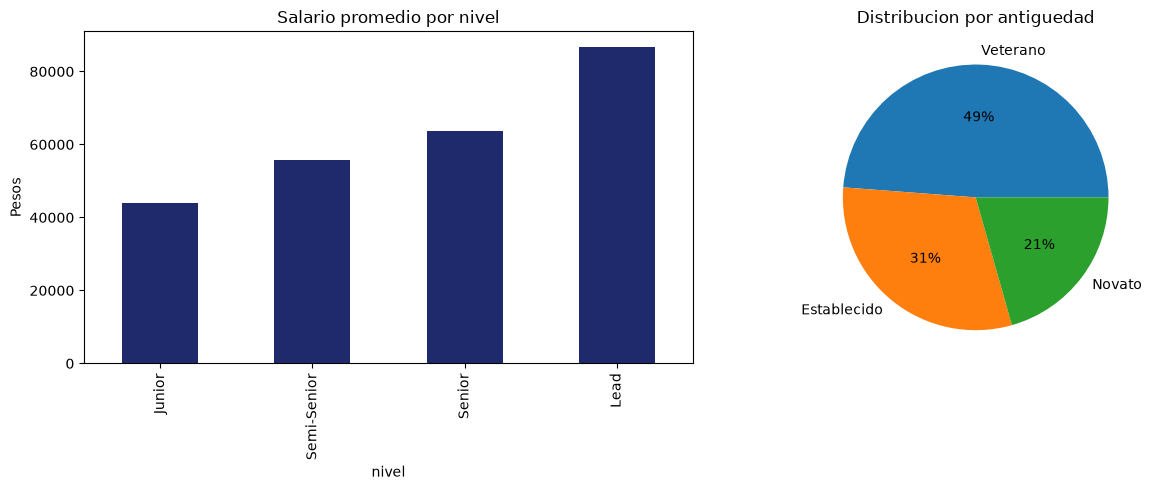

In [24]:
# Analisis: salario promedio por nivel (usando el dataset de empleados transformado)
print("Salario promedio por nivel:")
print(df.groupby("nivel")["salario_mensual"].mean().round(2).sort_values())

# Grafico
fig, axes = plt.subplots(1, 2, figsize=(13,5))
df.groupby("nivel")["salario_mensual"].mean().sort_values().plot(
    kind="bar", ax=axes[0], color="#1e2a6b")
axes[0].set_title("Salario promedio por nivel"); axes[0].set_ylabel("Pesos")
df["categoria_antiguedad"].value_counts().plot(kind="pie", ax=axes[1], autopct="%1.0f%%")
axes[1].set_title("Distribucion por antiguedad"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

> ✍️ **46.** ¿Qué nivel tiene el salario promedio más alto? ¿La codificación ordinal de `nivel` refleja correctamente esta jerarquía salarial?

> ✍️ **47.** ¿Cómo te ayudaron las transformaciones (codificación, features) a producir este análisis? ¿Podrías haber agrupado por nivel sin transformarlo?

> ✍️ **48.** De todas las técnicas de transformación (normalización, estandarización, codificación, feature engineering, fechas), ¿cuál te pareció más útil y por qué?

> ✍️ **49.** Un compañero normaliza los datos DESPUÉS de dividir en entrenamiento y prueba, usando el máximo de TODO el dataset. ¿Por qué esto es un error (fuga de datos / data leakage)? ¿Cómo debería hacerse?

> ✍️ **50 (reflexión).** En tu carrera de Ingeniería en Computación, ¿en qué proyecto real necesitarías transformar datos antes de analizarlos o modelarlos? Describe qué transformaciones aplicarías (ej. datos de sensores, logs con timestamps, categorías de usuarios).

**Respuestas:**

46. El nivel Lead tiene el salario promedio más alto: 86,666.09 pesos, seguido de Senior, Semi-Senior y Junior. Sí, la codificación ordinal refleja la jerarquía y coincide con el crecimiento salarial observado, aunque la codificación por sí sola no demuestra causalidad.

47. La codificación hizo utilizables las variables categóricas y las features resumieron productividad, antigüedad y desempeño. Sí se podía agrupar por `nivel` sin transformarlo, porque pandas maneja texto en `groupby`; la transformación es necesaria principalmente para modelos numéricos y análisis comparables.

48. La transformación de fechas me parece la más útil para RH porque convierte una fecha difícil de modelar en antigüedad, año, mes y día de semana. En otros modelos, la estandarización o el one-hot podrían ser más importantes; la utilidad depende del objetivo.

49. Usar el máximo de todo el dataset filtra información del conjunto de prueba al entrenamiento. El escalador debe ajustarse (`fit`) solo con train y después aplicar `transform` tanto a train como a test; así la evaluación representa datos realmente nuevos.

50. Aplicaría este flujo a un sistema de mantenimiento predictivo para sensores industriales. Limpiaría lecturas imposibles y faltantes, convertiría timestamps, extraería hora, turno y tiempo desde el último mantenimiento, estandarizaría sensores, codificaría tipo de máquina y ubicación, agregaría promedios y cambios por ventana temporal, y usaría un pipeline separado correctamente entre entrenamiento y prueba para evitar leakage.


---
# TAREA — Dataset limpio y documentado (con diccionario de datos)

Como tarea final, prepara un **dataset transformado, limpio y documentado**. Entrégalo junto con este cuaderno.

### Instrucciones

1. Toma el dataset de **empleados** (o el de Amazon) ya transformado con tu pipeline.
2. Guarda el resultado en un archivo CSV limpio con `df_transformado.to_csv("dataset_limpio.csv", index=False)`.
3. Crea un **diccionario de datos**: una tabla que documente CADA columna del dataset final.

### El diccionario de datos debe incluir, por cada columna:

| Columna | Tipo | Descripción | Transformación aplicada | Valores posibles / rango |
|---|---|---|---|---|
| salario_mensual | float | Salario mensual en pesos | Ninguna (original) | 10,000 – 90,000 |
| salario_z | float | Salario estandarizado | Z-score | media 0, desv 1 |
| nivel_cod | int | Nivel jerárquico codificado | Ordinal (1-4) | 1=Junior ... 4=Lead |
| ... | ... | ... | ... | ... |

Documenta **todas** las columnas del dataset transformado. Puedes crear el diccionario en una celda de código (como DataFrame) o en una celda de texto (tabla Markdown).


In [25]:
# TAREA: genera el diccionario de datos como un DataFrame y guarda el dataset limpio
# Ejemplo de estructura:
# diccionario = pd.DataFrame([
#     {"columna": "salario_mensual", "tipo": "float", "descripcion": "Salario mensual en pesos",
#      "transformacion": "ninguna", "rango": "10000-90000"},
#     {"columna": "salario_z", "tipo": "float", "descripcion": "Salario estandarizado",
#      "transformacion": "Z-score", "rango": "media 0, desv 1"},
#     # ... completa TODAS las columnas
# ])
# print(diccionario.to_string(index=False))
# df_transformado.to_csv("dataset_limpio.csv", index=False)
# diccionario.to_csv("diccionario_datos.csv", index=False)


---
## Cierre y entrega

Dominaste las cinco técnicas de transformación de datos: **normalización, estandarización, codificación categórica (ordinal, one-hot, label), feature engineering y manejo de fechas**. Además construiste un **pipeline reproducible** y documentaste un dataset con su **diccionario de datos**, tal como se hace en un proyecto profesional.

### Entrega en Google Classroom

1. Verifica que **todas las celdas corran sin error** (Entorno de ejecución → Ejecutar todo).
2. Confirma que respondiste las **50 preguntas ✍️** y los **9 retos de código**.
3. Adjunta el **dataset limpio** (`dataset_limpio.csv`) y el **diccionario de datos**.
4. **Archivo → Guardar una copia en Drive** y comparte el enlace en Classroom.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Todas las celdas se ejecutan correctamente | 10 |
| Retos de código resueltos (9) | 25 |
| Respuestas a las 50 preguntas ✍️ | 35 |
| Pipeline reproducible funcional | 10 |
| Dataset limpio + diccionario de datos | 15 |
| Orden y documentación | 5 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
*Datasets: empleados.csv, amazon.csv*
